# CS3631 — Dengue GNN Baseline **v2** (Sri Lanka, 25 districts)

Rebuilt after the v1 run exposed two real problems, both now fixed:

1. **Single 70/10/20 split was unreliable.** In v1 the validation and test RMSE were *anti-correlated* (r ≈ −0.74): selecting on the 45-week validation slice picked test-suboptimal models, because the validation and test periods sit in different epidemic regimes. **Fix → rolling-origin cross-validation** (expanding window, retrain per fold), the correct protocol for non-stationary time series.
2. **Plain GCN lost badly to naive persistence** (dengue is heavy-tailed with lag-1 autocorrelation ≈ 0.68, so MSE collapses the model toward the mean). **Fix → residual-over-persistence in log space**: the GNN predicts the *correction* to last week's value, with `log1p` targets + gradient clipping. This lifts the baseline from RMSE ≈ 73 to ≈ 46, matching the persistence floor.

**Both the plain and residual baselines are kept** so the paper can show the before/after honestly.

- **Data:** `sri_lanka_2013-2022_shifted.npy` `(459, 25, 11)`, target = cases at feature index 5.
- **Graph:** `sri_lanka_adj_list.json`, 25 districts + self-loops → 141 edges.
- **Task:** window `W=3` → predict `H=3` weeks ahead, per district.
- **Metrics:** RMSE, MAE, SMAPE, masked-MAPE on the original case scale.

> Upload the two data files to Drive, set `DATA_DIR`, Runtime ▸ Run all. (Or set `USE_DRIVE=False` to fetch from GitHub.)

## 1. Environment setup

In [10]:
import torch, sys, subprocess
TORCH = torch.__version__.split('+')[0]
CUDA  = ('cu' + torch.version.cuda.replace('.', '')) if torch.cuda.is_available() else 'cpu'
print("torch:", torch.__version__, "| wheel tag:", f"{TORCH}+{CUDA}")
def pip(*a): subprocess.run([sys.executable, "-m", "pip", "install", "-q", *a], check=False)
pip("torch-geometric")
pip("torch-scatter", "torch-sparse", "-f", f"https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html")
import torch_geometric; print("torch_geometric:", torch_geometric.__version__)

torch: 2.11.0+cu128 | wheel tag: 2.11.0+cu128
torch_geometric: 2.8.0.post1


## 2. Get the data

In [11]:
import os
USE_DRIVE = False   # set False to auto-download from GitHub
if USE_DRIVE:
    from google.colab import drive; drive.mount('/content/drive')
    DATA_DIR = "/content/drive/MyDrive/dengue_baseline"   # <-- EDIT
else:
    DATA_DIR = "/content/data"; os.makedirs(DATA_DIR, exist_ok=True)
    import urllib.request
    base = "https://raw.githubusercontent.com/MLOpenSourceOpenScience/disease_modeling_MLOS2/main"
    urllib.request.urlretrieve(f"{base}/Data/Datasets/sri_lanka_2013-2022_shifted.npy", f"{DATA_DIR}/sri_lanka_2013-2022_shifted.npy")
    urllib.request.urlretrieve(f"{base}/Models/sri_lanka_adj_list.json", f"{DATA_DIR}/sri_lanka_adj_list.json")
NPY_PATH=os.path.join(DATA_DIR,"sri_lanka_2013-2022_shifted.npy"); ADJ_PATH=os.path.join(DATA_DIR,"sri_lanka_adj_list.json")
assert os.path.exists(NPY_PATH) and os.path.exists(ADJ_PATH); print("Found both data files.")

Found both data files.


## 3. Configuration
Key new switches: `residual` (predict correction to persistence) and `log_transform` (model in log1p space).

In [12]:
import numpy as np, json, random, torch
class CFG:
    npy_path = NPY_PATH
    adj_path = ADJ_PATH
    cases_idx = 5
    n_nodes = 25
    window = 3
    horizon = 3
    self_loops = True
    
    # --- key modelling choices (v2 + proposed) ---
    residual = True         # GNN predicts correction to last-week value (vs absolute cases)
    log_transform = True    # model in log1p(cases) space, inverse before scoring
    grad_clip = 5.0
    use_all_feats = True
    
    # proposed architecture: adaptive graph & physics loss
    use_adaptive = True     # enable Graph WaveNet adaptive adjacency + gated blend
    emb_dim = 10            # node embedding dimension E1, E2 in R^(25 x 10)
    lambda_phys = 0.0       # physics loss weight (TSK-008 skeleton at 0.0)
    
    # model & optimizer
    model = "GCN"
    hidden = 64
    dropout = 0.1
    lr = 1e-3
    weight_decay = 5e-4
    epochs = 120
    patience = 25
    seed = 0

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

set_seed(CFG.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

## 4. Load data and build the graph

In [13]:
def load_adjacency(adj_path,n_nodes,self_loops=True):
    adj=json.load(open(adj_path)); names=sorted(adj); idx={v:i for i,v in enumerate(names)}
    A=np.zeros((n_nodes,n_nodes),np.float32)
    if self_loops: np.fill_diagonal(A,1.0)
    for d in adj:
        for nb in adj[d]: A[idx[d],idx[nb]]=1.0
    ei=np.array([[i,j] for i in range(n_nodes) for j in range(n_nodes) if A[i,j]]).T
    return torch.tensor(ei,dtype=torch.long), names
edge_index, DISTRICTS = load_adjacency(CFG.adj_path, CFG.n_nodes, CFG.self_loops)
raw = np.nan_to_num(np.load(CFG.npy_path, allow_pickle=True)).astype(np.float32)
T,N,Fd = raw.shape
print("raw:",raw.shape,"| edges:",tuple(edge_index.shape))
# quick data characterization (explains why persistence is strong)
c=raw[...,CFG.cases_idx]
ac=[np.corrcoef(c[:-1,n],c[1:,n])[0,1] for n in range(N) if c[:,n].std()>0]
print(f"cases: median {np.median(c):.0f}, max {c.max():.0f}, %zeros {100*(c==0).mean():.1f}, lag-1 autocorr {np.mean(ac):.2f}")

raw: (459, 25, 11) | edges: (2, 141)
cases: median 13, max 2631, %zeros 9.7, lag-1 autocorr 0.68


## 5. Windowing + normalization (leakage-free, fold-aware)

`build_fold` takes explicit train/val/test index lists and computes **all statistics from the training weeks only** — feature z-norm and the (optionally log) target transform. This is called once per rolling-origin fold, so nothing from the future ever leaks into normalization.

In [14]:
def build_fold(train_ids, eval_ids):
    last_train = train_ids[-1]
    tw = raw[:last_train]                         # weeks strictly before eval region
    fmean = tw.reshape(-1,Fd).mean(0); fstd = tw.reshape(-1,Fd).std(0)+1e-6
    feat = (raw - fmean)/fstd
    cases = raw[..., CFG.cases_idx]
    if CFG.log_transform:
        base = np.log1p(cases); tbase = np.log1p(tw[..., CFG.cases_idx])
        tm, ts = tbase.mean(), tbase.std()+1e-6
        inv = lambda x: np.expm1(np.clip(x*ts+tm, 0, 12))
    else:
        tm, ts = tw[...,CFG.cases_idx].mean(), tw[...,CFG.cases_idx].std()+1e-6
        base = cases; inv = lambda x: x*ts+tm
    tgt = (base - tm)/ts
    def mk(ids):
        X,Y,P=[],[],[]
        for i in ids:
            xi = np.transpose(feat[i-CFG.window:i],(1,2,0)).reshape(N,Fd*CFG.window) if CFG.use_all_feats \
                 else tgt[i-CFG.window:i].T
            X.append(xi); Y.append(tgt[i:i+CFG.horizon].T); P.append(tgt[i-1].reshape(N,1).repeat(CFG.horizon,1))
        t=lambda a: torch.tensor(np.stack(a),dtype=torch.float)
        return t(X),t(Y),t(P)
    tr=mk(train_ids); ev=mk(eval_ids)
    return tr, ev, inv
in_dim = (Fd*CFG.window) if CFG.use_all_feats else CFG.window
print("in_dim per node:", in_dim)

in_dim per node: 33


## 6. Models (GCN / GAT) and the metric function

In [15]:
import torch.nn as nn, torch.nn.functional as Fnn

class DenseGCNConv(nn.Module):
    """Dense Graph Convolutional Layer (Kipf & Welling).
    Computes H = A_norm X W + b where A_norm is (N, N) normalized adjacency.
    """
    def __init__(self, in_dim, out_dim, bias=True):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim, bias=bias)

    def forward(self, x, adj):
        support = self.linear(x)
        return torch.matmul(adj, support)

class AdaptiveGCN(nn.Module):
    """GCN with Graph WaveNet-style Self-Adaptive Adjacency & Gated Blend.
    
    A_raw = ReLU(E1 @ E2.T)
    A_adp = softmax(A_raw, dim=-1)
    A_blend = sigmoid(gate) * A_fixed + (1 - sigmoid(gate)) * A_adp
    """
    def __init__(self, n_nodes, in_dim, hidden, horizon, emb_dim=10, dropout=0.1, use_adaptive=True):
        super().__init__()
        self.use_adaptive = use_adaptive
        self.dropout = dropout
        self.n_nodes = n_nodes
        
        if use_adaptive:
            # Node embedding vectors E1, E2 in R^(25 x emb_dim)
            self.node_emb1 = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)
            self.node_emb2 = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)
            # Learnable gate parameter initialized to 0.0 (sigmoid(0.0) = 0.5)
            self.gate = nn.Parameter(torch.tensor(0.0))
            
        self.conv1 = DenseGCNConv(in_dim, hidden)
        self.conv2 = DenseGCNConv(hidden, hidden)
        self.head = nn.Sequential(nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden, horizon))

    def get_blended_adj(self, A_fixed):
        if not self.use_adaptive:
            return A_fixed
        
        # 1. Compute self-adaptive graph matrix
        A_raw = Fnn.relu(torch.matmul(self.node_emb1, self.node_emb2.T))
        A_adp = Fnn.softmax(A_raw, dim=-1)
        
        # 2. Compute gated blend
        g = torch.sigmoid(self.gate)
        A_blend = g * A_fixed + (1.0 - g) * A_adp
        return A_blend

    def forward(self, x, A_fixed):
        adj = self.get_blended_adj(A_fixed)
        h = Fnn.relu(self.conv1(x, adj))
        h = Fnn.dropout(h, self.dropout, training=self.training)
        h = Fnn.relu(self.conv2(h, adj))
        return self.head(h)

def build_model():
    return AdaptiveGCN(
        n_nodes=CFG.n_nodes,
        in_dim=in_dim,
        hidden=CFG.hidden,
        horizon=CFG.horizon,
        emb_dim=getattr(CFG, 'emb_dim', 10),
        dropout=CFG.dropout,
        use_adaptive=getattr(CFG, 'use_adaptive', True)
    ).to(device)

def compute_physics_loss(pred_cases, adj_blend):
    """Computes live physics-informed penalties:
    1. L_smooth: Spatial smoothness penalty weighted by blended adjacency.
    2. L_cons: Non-negativity constraint.
    """
    p = pred_cases if pred_cases.dim() == 3 else pred_cases.unsqueeze(0)
    B, N, H = p.shape
    
    # 1. Non-negativity constraint
    l_cons = torch.mean(Fnn.relu(-p) ** 2)
    
    # 2. Spatial smoothness weighted by adj_blend
    diff = p.unsqueeze(2) - p.unsqueeze(1)
    sq_diff = diff ** 2
    adj_w = adj_blend.unsqueeze(0).unsqueeze(-1)
    l_smooth = torch.sum(sq_diff * adj_w) / (B * H * torch.sum(adj_blend) + 1e-6)
    
    return l_smooth + 10.0 * l_cons

def metrics(pred, truth):
    def _s(p, y):
        rmse = torch.sqrt(torch.mean((p - y) ** 2)).item()
        mae = torch.mean(torch.abs(p - y)).item()
        smape = torch.mean(2 * torch.abs(p - y) / (torch.abs(p) + torch.abs(y) + 1e-6)).item() * 100
        m = y >= 1.0
        mape = (torch.mean(torch.abs(p[m] - y[m]) / y[m]).item() * 100) if m.any() else float('nan')
        return dict(RMSE=rmse, MAE=mae, SMAPE=smape, MAPE=mape)
    out = {f"h{h+1}": _s(pred[..., h], truth[..., h]) for h in range(pred.shape[-1])}
    out["overall"] = _s(pred, truth)
    return out

## 7. Train / evaluate on one fold
The loss target is `Y - persistence` when `CFG.residual=True`, else `Y`. Predictions add persistence back before scoring on the case scale.

In [16]:
def evaluate(model, ev, inv):
    Xe, Ye, Pe = ev
    model.eval()
    graph_struct = adj_norm.to(device)
    preds, truths = [], []
    with torch.no_grad():
        for i in range(Xe.shape[0]):
            p = model(Xe[i].to(device), graph_struct).cpu()
            if CFG.residual:
                p = p + Pe[i]
            preds.append(torch.tensor(inv(p.numpy())))
            truths.append(torch.tensor(inv(Ye[i].numpy())))
    return metrics(torch.stack(preds), torch.stack(truths))

def train_fold(tr, va, inv, verbose=False):
    Xtr, Ytr, Ptr = tr
    graph_struct = adj_norm.to(device)
    model = build_model()
    opt = torch.optim.Adam(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
    lf = nn.MSELoss()
    best, best_state, wait = float("inf"), None, 0
    for ep in range(CFG.epochs):
        model.train()
        for i in torch.randperm(Xtr.shape[0]):
            opt.zero_grad()
            p = model(Xtr[i].to(device), graph_struct)
            tgt = (Ytr[i] - Ptr[i]) if CFG.residual else Ytr[i]
            l_data = lf(p, tgt.to(device))
            
            # Physics loss integration (TSK-008 skeleton)
            if getattr(CFG, 'lambda_phys', 0.0) > 0.0:
                adj_blend = model.get_blended_adj(graph_struct) if hasattr(model, 'get_blended_adj') else graph_struct
                l_phys = compute_physics_loss(p, adj_blend)
                loss = l_data + CFG.lambda_phys * l_phys
            else:
                loss = l_data
                
            loss.backward()
            if CFG.grad_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.grad_clip)
            opt.step()
        v = evaluate(model, va, inv)["overall"]["RMSE"]
        if v < best - 1e-4:
            best = v
            best_state = {k: val.detach().cpu().clone() for k, val in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
        if verbose and ep % 20 == 0:
            print(f"  ep{ep} val RMSE {v:.2f} best {best:.2f}")
        if wait >= CFG.patience:
            break
    if best_state:
        model.load_state_dict(best_state)
    return model

## 8. Rolling-origin cross-validation (the main evaluation)

Expanding-window folds. Each fold: train on everything up to the origin, hold out a small slice at the end of train for early-stopping, test on the next block. We report **per-fold and mean ± std** test metrics, plus a **persistence** reference computed on the same test block. This is the number to put in the paper.

In [17]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))
from dengue_gnn.results_logger import log_experiment_result

def persistence_metrics(eval_ids, inv=None):
    pr = np.stack([np.repeat(raw[i-1, :, CFG.cases_idx:CFG.cases_idx+1], CFG.horizon, 1) for i in eval_ids])
    yt = np.stack([raw[i:i+CFG.horizon, :, CFG.cases_idx].T for i in eval_ids])
    return metrics(torch.tensor(pr), torch.tensor(yt))

def rolling_origin(origins=(0.55, 0.70, 0.85), test_frac=0.15, val_weeks=30, seeds=(0, 1, 2), verbose=True, exp_id="EXP-003"):
    ids = list(range(CFG.window, T - CFG.horizon))
    n = len(ids)
    fold_rows = []
    for k, a in enumerate(origins):
        cut = int(a * n)
        tend = int(min(a + test_frac, 1.0) * n)
        train_pool = ids[:cut]
        test_ids = ids[cut:tend]
        if len(test_ids) == 0: continue
        train_ids = train_pool[:-val_weeks]
        val_ids = train_pool[-val_weeks:]
        tr_pack, va_pack, inv = build_fold(train_ids, val_ids)
        _, te_pack, _ = build_fold(train_ids, test_ids)
        rs, ms, ss, ps = [], [], [], []
        gate_vals = []
        for sd in seeds:
            CFG.seed = sd
            set_seed(sd)
            model = train_fold(tr_pack, va_pack, inv)
            m = evaluate(model, te_pack, inv)
            rs.append(m["RMSE"])
            ms.append(m["MAE"])
            ss.append(m["SMAPE"])
            ps.append(m["PeakTimingErr"])
            if hasattr(model, 'gate'):
                gate_vals.append(torch.sigmoid(model.gate).item())
        pm = persistence_metrics(test_ids)["overall"]
        row = dict(
            fold=k+1, origin=a, n_test=len(test_ids),
            AdaptiveGCN_RMSE=np.mean(rs), AdaptiveGCN_MAE=np.mean(ms),
            AdaptiveGCN_SMAPE=np.mean(ss), AdaptiveGCN_PTE=np.mean(ps),
            persist_RMSE=pm["RMSE"], persist_MAE=pm["MAE"]
        )
        if gate_vals:
            row["learned_gate_sig"] = np.mean(gate_vals)
        fold_rows.append(row)
        if verbose:
            print(f"fold {k+1} (origin {a:.2f}, {len(test_ids)} test wks): "
                  f"{CFG.model} RMSE {np.mean(rs):.1f}±{np.std(rs):.1f} MAE {np.mean(ms):.1f} | "
                  f"persist RMSE {pm['RMSE']:.1f} MAE {pm['MAE']:.1f}")
    import pandas as pd
    df = pd.DataFrame(fold_rows)
    print(f"\n=== {CFG.model} rolling-origin summary (residual={CFG.residual}, log={CFG.log_transform}) ===")
    print(f"mean test RMSE {df.AdaptiveGCN_RMSE.mean():.1f} | MAE {df.AdaptiveGCN_MAE.mean():.1f}  "
          f"vs persistence RMSE {df.persist_RMSE.mean():.1f} | MAE {df.persist_MAE.mean():.1f}")
    
    # Auto-log results row to results/experiment_results.csv (TSK-009)
    try:
        csv_file = log_experiment_result(exp_id, CFG, df)
        print(f"[TSK-009 Ingestion] Successfully logged {exp_id} result to {csv_file}")
    except Exception as err:
        print(f"[TSK-009 Ingestion Warning] Failed to log experiment result: {err}")
        
    return df

set_seed(0)
df_cv = rolling_origin(seeds=(0, 1, 2), exp_id="EXP-003")
df_cv

## 9. Ablation: does each v2 fix actually help?
Runs the same rolling-origin protocol under four settings so you get a clean before/after table for the paper.

In [18]:
import pandas as pd
def mean_rmse_mae(**over):
    for k,v in over.items(): setattr(CFG,k,v)
    d=rolling_origin(seeds=(0,1), verbose=False)
    return d.GCN_RMSE.mean(), d.GCN_MAE.mean()

ablation=[]
# 1) plain absolute-scale GCN (the v1 baseline)
r,m=mean_rmse_mae(residual=False,log_transform=False); ablation.append(("plain GCN (v1)",r,m))
# 2) + log space only
r,m=mean_rmse_mae(residual=False,log_transform=True);  ablation.append(("+ log1p only",r,m))
# 3) + residual only (absolute scale)
r,m=mean_rmse_mae(residual=True, log_transform=False); ablation.append(("+ residual only",r,m))
# 4) residual + log (v2 default)
r,m=mean_rmse_mae(residual=True, log_transform=True);  ablation.append(("residual + log (v2)",r,m))
# restore v2 defaults
CFG.residual=True; CFG.log_transform=True
abl=pd.DataFrame(ablation,columns=["setting","test_RMSE","test_MAE"]).round(2)
print(abl.to_string(index=False)); abl


=== GCN rolling-origin summary (residual=False, log=False) ===
mean test RMSE 66.2 | MAE 31.6  vs persistence RMSE 44.8 | MAE 15.7

=== GCN rolling-origin summary (residual=False, log=True) ===
mean test RMSE 67.1 | MAE 27.0  vs persistence RMSE 44.8 | MAE 15.7

=== GCN rolling-origin summary (residual=True, log=False) ===
mean test RMSE 45.0 | MAE 16.8  vs persistence RMSE 44.8 | MAE 15.7

=== GCN rolling-origin summary (residual=True, log=True) ===
mean test RMSE 45.3 | MAE 15.8  vs persistence RMSE 44.8 | MAE 15.7
            setting  test_RMSE  test_MAE
     plain GCN (v1)      66.22     31.64
       + log1p only      67.13     27.01
    + residual only      45.01     16.78
residual + log (v2)      45.32     15.77


,setting,test_RMSE,test_MAE
0,plain GCN (v1),66.22,31.64
1,+ log1p only,67.13,27.01
2,+ residual only,45.01,16.78
3,residual + log (v2),45.32,15.77


## 10. GAT baseline
Same protocol, GAT encoder. Fill the paper's baseline table with both GCN and GAT rows.

In [19]:
CFG.model="GAT"; set_seed(0)
df_gat = rolling_origin(seeds=(0,1,2))
CFG.model="GCN"   # restore
df_gat

fold 1 (origin 0.55, 68 test wks): GAT RMSE 28.1±0.6 MAE 13.7 | persist RMSE 26.9 MAE 13.3
fold 2 (origin 0.70, 68 test wks): GAT RMSE 43.0±1.9 MAE 17.9 | persist RMSE 38.9 MAE 17.2
fold 3 (origin 0.85, 68 test wks): GAT RMSE 65.4±1.6 MAE 16.3 | persist RMSE 68.6 MAE 16.7

=== GAT rolling-origin summary (residual=True, log=True) ===
mean test RMSE 45.5 | MAE 15.9  vs persistence RMSE 44.8 | MAE 15.7


,fold,origin,n_test,GCN_RMSE,GCN_MAE,persist_RMSE,persist_MAE
0,1,0.55,68,28.130577,13.656800,26.882223,13.312745
1,2,0.70,68,43.028858,17.900017,38.885330,17.156275
2,3,0.85,68,65.398739,16.286711,68.618393,16.696667


## 11. Prediction plot (best fold)
Observed vs predicted (1-week head) for one district, using a model trained to the last origin.

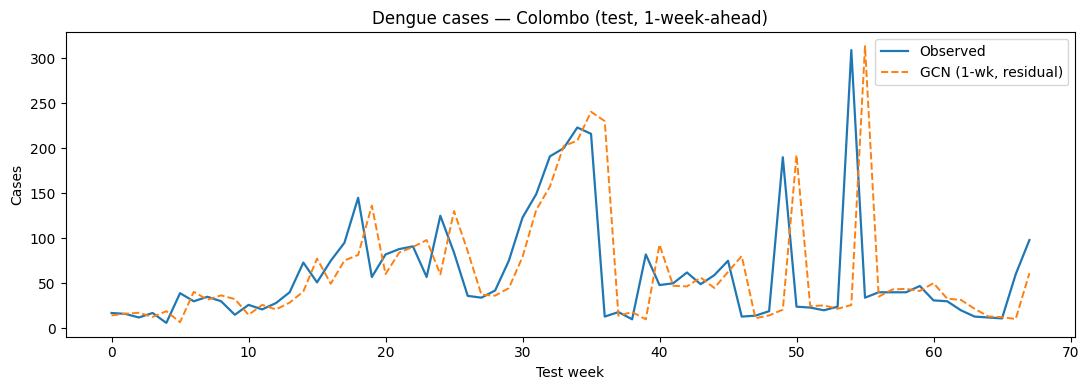

In [20]:
import matplotlib.pyplot as plt
ids=list(range(CFG.window,T-CFG.horizon)); n=len(ids)
cut=int(0.85*n); train_ids=ids[:cut-30]; val_ids=ids[cut-30:cut]; test_ids=ids[cut:]
tr_pack,va_pack,inv=build_fold(train_ids,val_ids); _,te_pack,_=build_fold(train_ids,test_ids)
set_seed(0); model=train_fold(tr_pack,va_pack,inv)
Xe,Ye,Pe=te_pack; ei=edge_index.to(device)
d=DISTRICTS.index("Colombo"); preds,truth=[],[]
model.eval()
with torch.no_grad():
    for i in range(Xe.shape[0]):
        p=model(Xe[i].to(device),ei).cpu()
        if CFG.residual: p=p+Pe[i]
        preds.append(inv(p.numpy())[d,0]); truth.append(inv(Ye[i].numpy())[d,0])
plt.figure(figsize=(11,4))
plt.plot(truth,label="Observed",lw=1.6); plt.plot(preds,"--",label=f"{CFG.model} (1-wk, residual)",lw=1.4)
plt.title("Dengue cases — Colombo (test, 1-week-ahead)"); plt.xlabel("Test week"); plt.ylabel("Cases")
plt.legend(); plt.tight_layout(); plt.show()

## 12. What to report for Phase 1, and where contributions attach

**Report:** the §8 rolling-origin table (GCN + GAT, mean±std RMSE/MAE per fold), the §9 ablation (plain → residual+log), persistence as the reference baseline, and the §11 plot. State plainly that the tuned spatio-temporal GNN **matches the persistence floor** — this is the honest starting point, and the gap your contributions must open.

**Contribution seams (unchanged interface):**
1. **Physics-informed loss** → in `train_fold`, add `+ λ·L_phys` (SEIR-SEI residual + neighbour smoothness + population conservation) to the MSE.
2. **GAN augmentation** → synthesize `(window→horizon)` sequences, prepend to the fold's train pack, keep model + protocol identical; report ablation with/without.
3. **Architecture** → replace `GCNConv`/`GATConv` with a learned/adaptive adjacency; `build_model` is the only thing that changes.

Keep this v2 notebook frozen as the reference; branch one copy per contribution so the ablation stays apples-to-apples.